# Objectif du notebook 

Date de création :30/03/2026

À compléter 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar

In [4]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": BandFilter(order=4, lowcut=100, highcut=900),
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    "tau_rtf_analysis": 3,
    "alpha_overlap": 0.25,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [5]:
rtf_mfp_processor.fsm_passive.cm.nperseg

4096

In [6]:
rtf_mfp_processor.fsm_nperseg

8192

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [7]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [8]:
# seq_id = 144
# df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# # Select only pulses emitted between OBS1 and OBS3
# pulse_slice = (40, 180)
# df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

# root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
# if not os.path.exists(root_fig):
#     os.makedirs(root_fig)

# Calcul RTF pour une séquence passive 


In [9]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0.75,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study below 
    "tau_rtf_analysis": 3.0,
    "alpha_overlap": 0.9,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [10]:
###########################
# Dummy
###########################
id_library = 50


# id_library = 11
active_replicas_args = {
    "replica_sequence_ids": [],
    "replica_pulse_slice": [],
    "load_precomputed_feature": False,
}

passive_replicas_args = {
    "start_datetimes": [
        datetime(year=2025, month=10, day=14, hour=1, minute=30, second=00),  
        # datetime(year=2025, month=10, day=14, hour=1, minute=42, second=00),  # OK
        # datetime(year=2025, month=10, day=15, hour=10, minute=14, second=00),  # OK
    ],
    "end_datetimes": [
        datetime(year=2025, month=10, day=14, hour=1, minute=50, second=00),  
        # datetime(year=2025, month=10, day=14, hour=1, minute=48, second=00),  # OK
        # datetime(year=2025, month=10, day=15, hour=10, minute=18, second=00),  # OK
    ],
    "load_precomputed_feature": False,
}

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
)


Deriving features for active source...

Deriving replicas for passive source...

RTF processing of passive recording
RTF feature estimation...
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%Using first vessel in list (default behavior) : mmsi=227315990
A library dataset with ID 50 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_50.nc.


In [11]:
print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)


4096 2048


In [12]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_50.nc"
ds = xr.open_dataset(fpath)
ds

# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_11.nc"
# ds1 = xr.open_dataset(fpath)
# ds1

<xarray.Dataset> Size: 110MB
Dimensions:       (h_index: 3, f_rtf: 4097, replica_id: 956)
Coordinates:
  * h_index       (h_index) int32 12B 1 2 3
  * f_rtf         (f_rtf) float32 16kB 0.0 0.2441 0.4883 ... 999.5 999.8 1e+03
  * replica_id    (replica_id) int32 4kB 0 1 2 3 4 5 ... 950 951 952 953 954 955
Data variables:
    rtf_amp       (h_index, f_rtf, replica_id) float32 47MB ...
    rtf_phase     (h_index, f_rtf, replica_id) float32 47MB ...
    feature_psd   (f_rtf, replica_id) float32 16MB ...
    e_replica     (replica_id) float32 4kB ...
    n_replica     (replica_id) float32 4kB ...
    u_replica     (replica_id) float32 4kB ...
    replica_type  (replica_id) int32 4kB ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     50

## Définition des fonctions utiles 

In [13]:
def interp_deconvolution(ds):
    f_interp = ds.f_rtf.values
    freq_deconv = ds.f_deconv.values

    # Interpolate rtf_deconv at rtf frequencies
    # Interp module
    interpolator_module = interp1d(
        freq_deconv, ds.rtf_amp_deconv.values, axis=1, fill_value="extrapolate"
    )
    rtf_deconvolution_module_interp = interpolator_module(f_interp)

    # Interp unwrapped phase
    unwrapped_phase_deconv = np.unwrap(ds.rtf_phase_deconv.values, axis=1)
    interpolator_phase = interp1d(
        freq_deconv, unwrapped_phase_deconv, axis=1, fill_value="extrapolate"
    )
    rtf_deconvolution_phase_unwrapped_interp = interpolator_phase(f_interp)
    # Wrap the interpolated unwrapped phase back to [-pi, pi]
    rtf_deconvolution_phase_interp = (rtf_deconvolution_phase_unwrapped_interp + np.pi) % (2 * np.pi) - np.pi

    # Build interpolated complex RTF
    rtf_deconvolution_interp = rtf_deconvolution_module_interp * np.exp(1j * rtf_deconvolution_phase_interp)

    return f_interp, rtf_deconvolution_interp

In [14]:
def plot_features_ipulse(
    rtf_cs_evd,
    rtf_deconvolution_interp,
    freq,
    i_pulse=0,
    rtf_deconvolution=None,
    freq_deconv=None,
    save=False, 
    root_img=None, 
):
    n_rcv = rtf_cs_evd.shape[0]
    # Compare module
    fig, ax_mod = plt.subplots(
        nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
    )

    # Module
    for i_rcv in range(n_rcv):
        h_plot = i_rcv + 1

        ax_mod[i_rcv].plot(freq, np.abs(rtf_cs_evd[i_rcv, :, i_pulse]), label="CS-EVD", color=color(0))


        ax_mod[i_rcv].set_title(f"OBS {h_plot}")
        ax_mod[i_rcv].set_ylim([0.001, 1000])
        ax_mod[i_rcv].set_yscale("log")
        ax_mod[i_rcv].set_xlabel("")
        ax_mod[i_rcv].set_ylabel(r"$|\Pi|$")
        ax_mod[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

    set_subfigures_abc_labels(
        axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
    )
    fig.supxlabel("Frequency [Hz]")

    if save and root_img is not None: 
        fpath = os.path.join(root_img, f"rtf_cs_evd_module_replica_{i_pulse}.png")
        plt.savefig(fpath)

    # Wrapped phase
    fig, ax_phase_wrapped = plt.subplots(
        nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
    )
    for i_rcv in range(n_rcv):
        h_plot = i_rcv + 1

        ax_phase_wrapped[i_rcv].plot(freq, np.angle(rtf_cs_evd[i_rcv, :, i_pulse]), label="CS-EVD", color=color(0))
        ax_phase_wrapped[i_rcv].plot(freq, np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse]), label="Deconvolution Interp", color=color(1), linestyle="-")

        if rtf_deconvolution is not None and freq_deconv is not None:
            ax_phase_wrapped[i_rcv].plot(
                freq_deconv,
                np.angle(rtf_deconvolution[i_rcv, :, i_pulse]),
                label="Deconvolution",
                color=color(2),
                linestyle="--",
            )
        ax_phase_wrapped[i_rcv].set_title(f"OBS {h_plot}")
        ax_phase_wrapped[i_rcv].set_xlabel("")
        ax_phase_wrapped[i_rcv].set_ylabel(r"Phase [rad]")
        ax_phase_wrapped[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

    set_subfigures_abc_labels(
        axs=ax_phase_wrapped, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
    )
    fig.supxlabel("Frequency [Hz]")

    if save and root_img is not None: 
        fpath = os.path.join(root_img, f"rtf_deconv_vs_cs_evd_phase_replica_{i_pulse}.png")
        plt.savefig(fpath)

    # Unwrapped phase
    fig, ax_phase = plt.subplots(
        nrows=n_rcv, ncols=1, sharex=True, sharey="row", figsize=(16, 3 * n_rcv)
    )
    for i_rcv in range(n_rcv):
        h_plot = i_rcv + 1

        ax_phase[i_rcv].plot(freq, np.unwrap(np.angle(rtf_cs_evd[i_rcv, :, i_pulse])), label="CS-EVD", color=color(0))
        ax_phase[i_rcv].plot(freq, np.unwrap(np.angle(rtf_deconvolution_interp[i_rcv, :, i_pulse])), label="Deconvolution Interp", color=color(1), linestyle="-")

        if rtf_deconvolution is not None and freq_deconv is not None:
            ax_phase[i_rcv].plot(
                freq_deconv,
                np.unwrap(np.angle(rtf_deconvolution[i_rcv, :, i_pulse])),
                label="Deconvolution",
                color=color(2),
                linestyle="--",
            )

        ax_phase[i_rcv].set_title(f"OBS {h_plot}")
        ax_phase[i_rcv].set_xlabel("")
        ax_phase[i_rcv].set_ylabel(r"Phase [rad]")
        ax_phase[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

    set_subfigures_abc_labels(
        axs=ax_phase, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
    )
    fig.supxlabel("Frequency [Hz]")

    if save and root_img is not None: 
        fpath = os.path.join(root_img, f"rtf_deconv_vs_cs_evd_unwrapped_phase_replica_{i_pulse}.png")
        plt.savefig(fpath)


### Illustration sur un pulse 

In [15]:
# Select frequency range
fmin = 400
fmax = 800
ds = ds.sel(f_rtf=slice(fmin, fmax))

freq = ds.f_rtf.values

# Build complex RTFs
rtf_cs_evd = ds.rtf_amp * np.exp(1j * ds.rtf_phase)


In [16]:
fig_folder = os.path.join(sensibility_img_folder, "passive", f"library_{ds.id}")
os.makedirs(fig_folder, exist_ok=True)

In [17]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)

In [18]:
dist_rcv = get_dist_to_rcv(ds)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds.replica_id.values

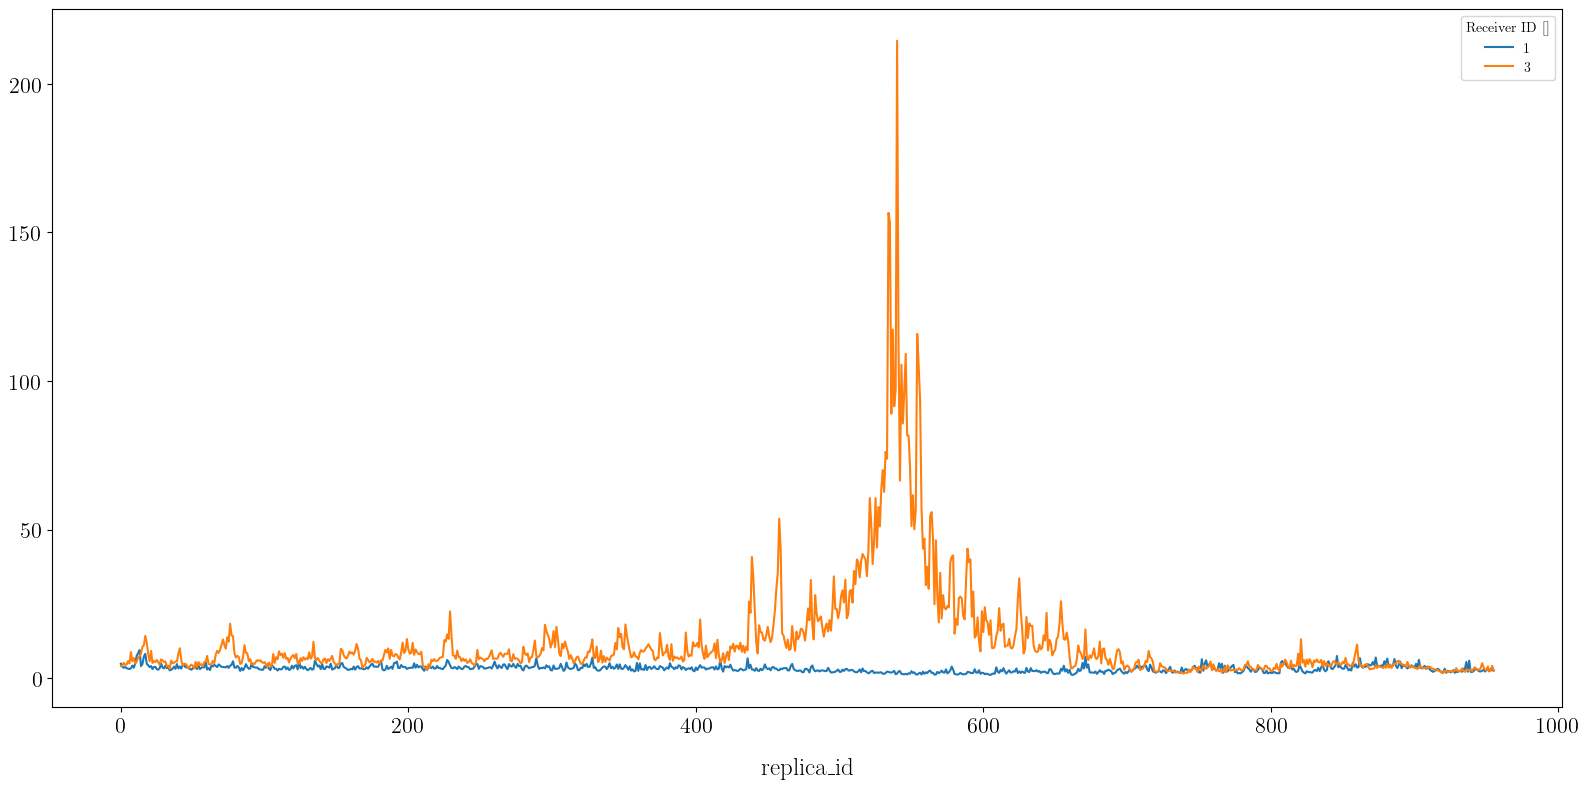

In [19]:
print()
# fig, axs = plt.subplots(2, 1, sharex=True)
np.abs(rtf_cs_evd).max(dim="f_rtf").sel(h_index=[idx for idx in rtf_cs_evd.h_index.values if idx != ds.reference_receiver_id]).plot(hue="h_index")
# np.abs(rtf_cs_evd).max(dim="f_rtf").sel(
#     h_index=[
#         idx for idx in rtf_cs_evd.h_index.values if idx != ds.reference_receiver_id
#     ]
# ).plot(ax=axs[0], hue="h_index")

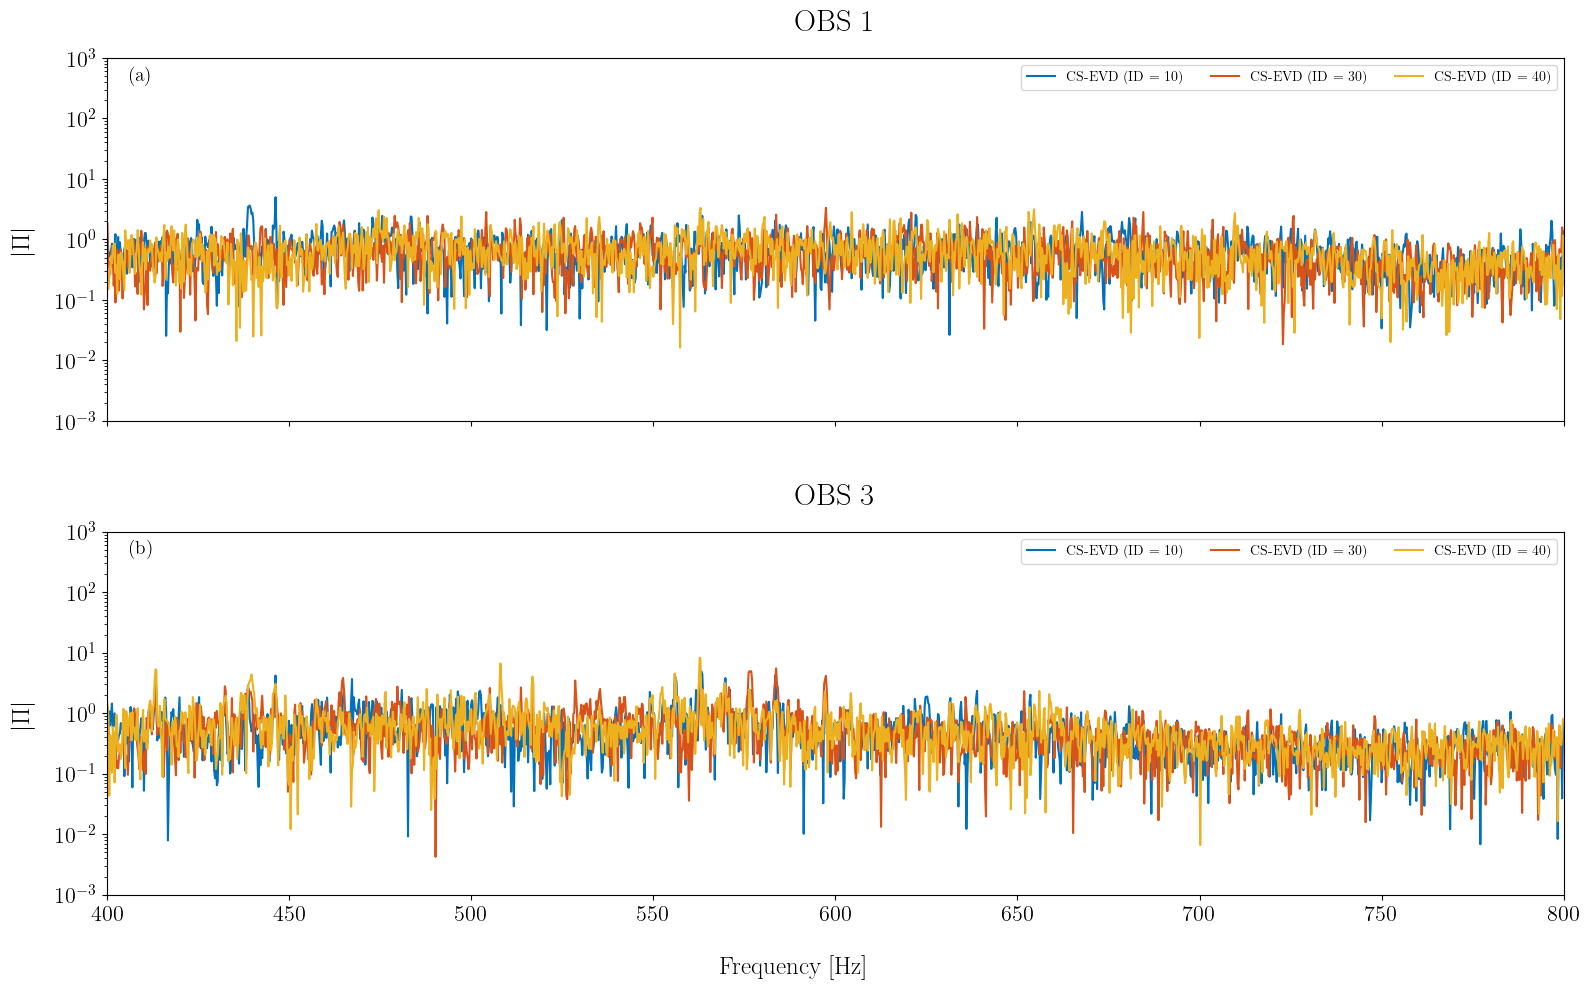

In [20]:
fmin_plot = 400
f_max_plot = 800

rep_selection = [10, 30, 40]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]
# i_rcv_plot = [np.argmin(np.abs(ds.h_index.values - idx)) for idx in idx_rcv_plot]
# print(i_rcv_plot)

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    #
    # h_plot = i_rcv + 1
    h_plot = id_rcv

    for i, i_pulse in enumerate(rep_selection):

        ax_mod[i_ax].plot(
            freq,
            np.abs(rtf_cs_evd[i_rcv, :, i_pulse]),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )


        ax_mod[i_ax].set_title(f"OBS {h_plot}")
        ax_mod[i_ax].set_ylim([0.001, 1000])
        ax_mod[i_ax].set_yscale("log")
        ax_mod[i_ax].set_xlabel("")
        ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
        ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
plt.savefig(fpath)

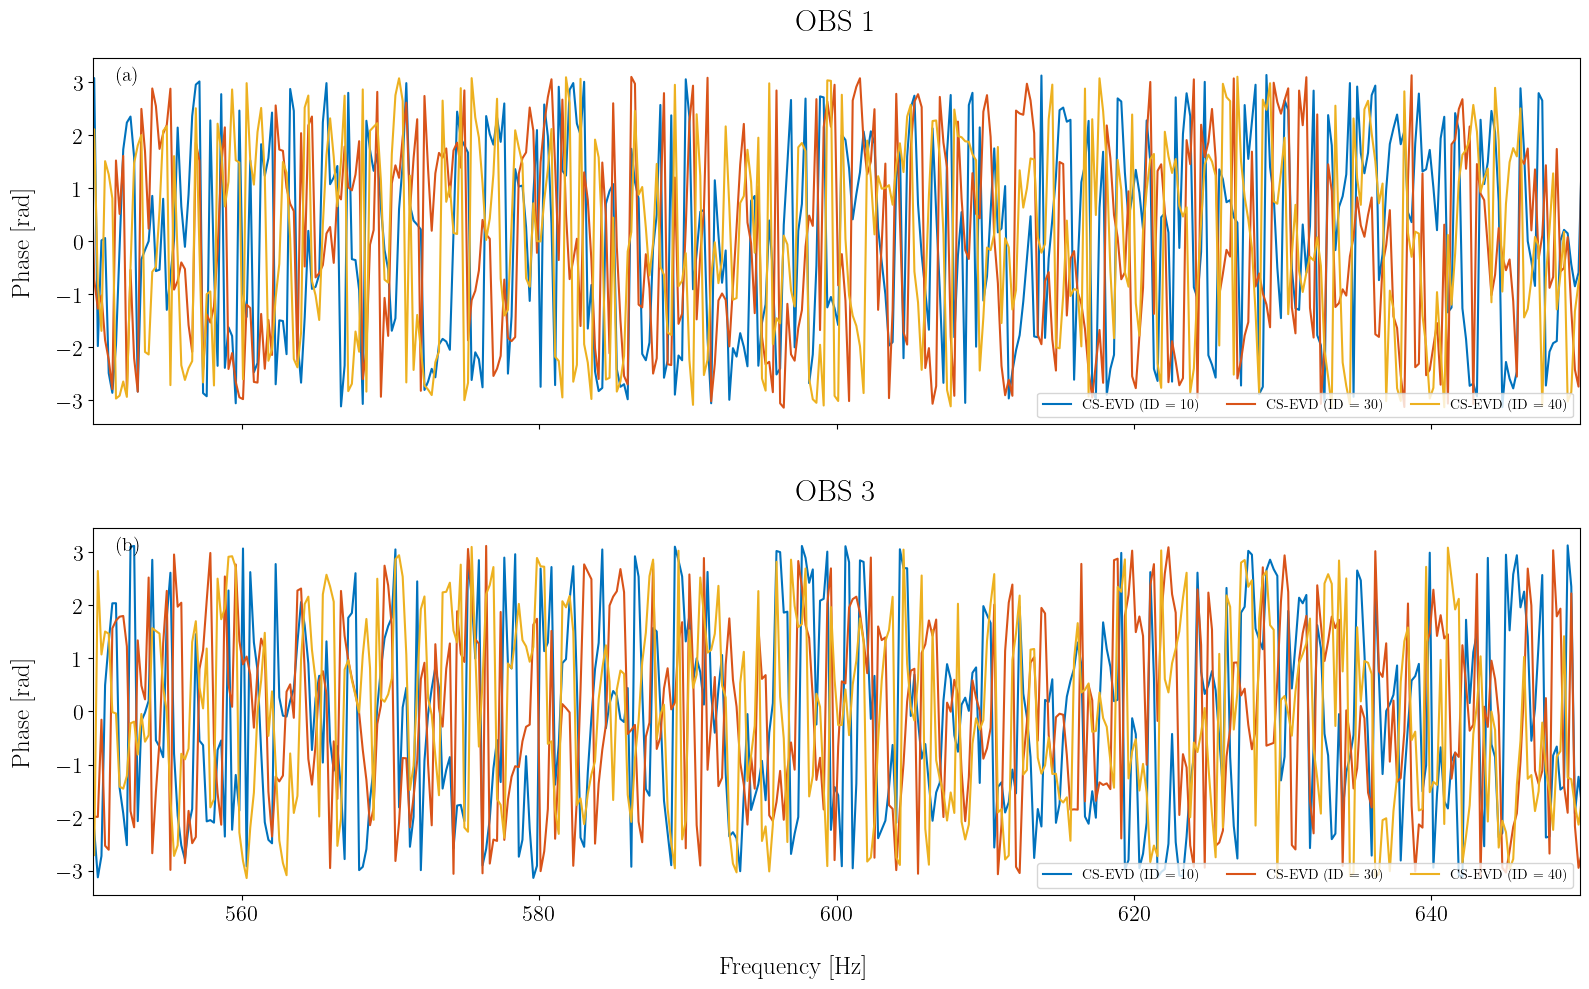

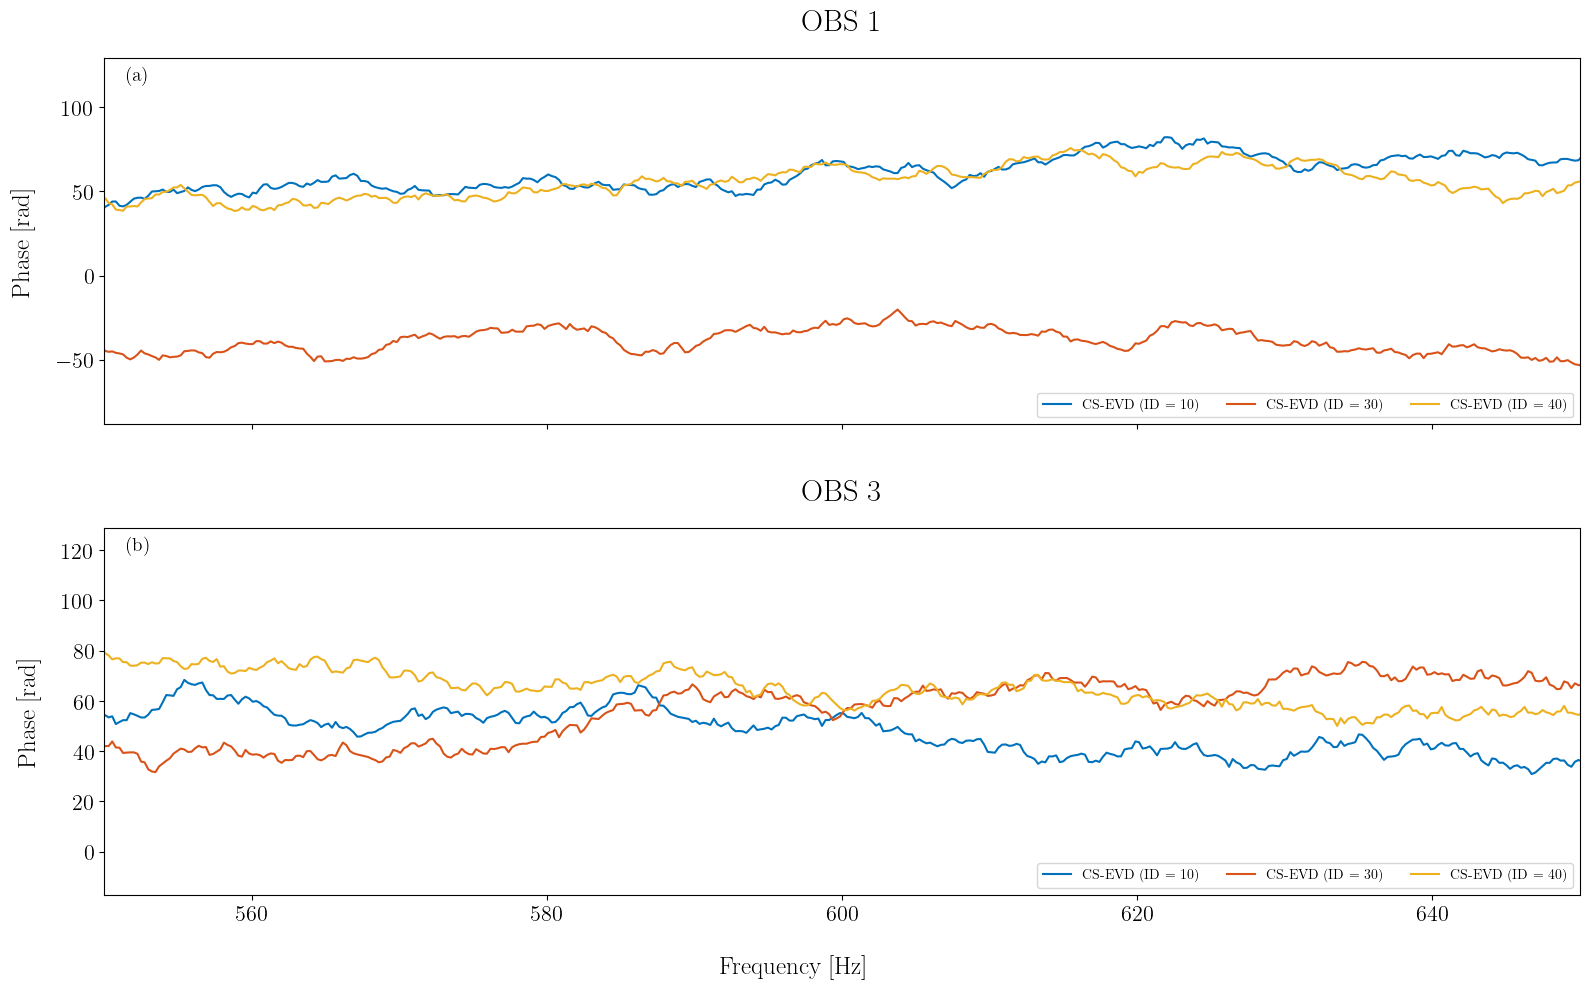

In [21]:
fmin_plot = 550
f_max_plot = 650

# Wrapped phase
fig, ax_phase_wrapped = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
i_ax = 0

for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))
    h_plot = i_rcv + 1

    for i, i_pulse in enumerate(rep_selection):
        ax_phase_wrapped[i_ax].plot(
            freq,
            np.angle(rtf_cs_evd[i_rcv, :, i_pulse]),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )

    ax_phase_wrapped[i_ax].set_title(f"OBS {h_plot}")
    ax_phase_wrapped[i_ax].set_xlabel("")
    ax_phase_wrapped[i_ax].set_ylabel(r"Phase [rad]")
    ax_phase_wrapped[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_phase_wrapped, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_phase_at_identified_pos.png")
plt.savefig(fpath)


# Unwrapped phase
fig, ax_phase = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)
i_ax = 0

for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    h_plot = i_rcv + 1

    for i, i_pulse in enumerate(rep_selection):

        ax_phase[i_ax].plot(
            freq,
            np.unwrap(np.angle(rtf_cs_evd[i_rcv, :, i_pulse])),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )
        
    ax_phase[i_ax].set_title(f"OBS {h_plot}")
    ax_phase[i_ax].set_xlabel("")
    ax_phase[i_ax].set_ylabel(r"Phase [rad]")
    ax_phase[i_ax].legend(fontsize=10, ncol=3, loc="lower right")

    i_ax += 1 

set_subfigures_abc_labels(
    axs=ax_phase, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

fpath = os.path.join(fig_folder, "rtf_unwrapped_phase_at_identified_pos.png")
plt.savefig(fpath)

## Variations du module autour d'une réplique 

(400.0, 800.0)

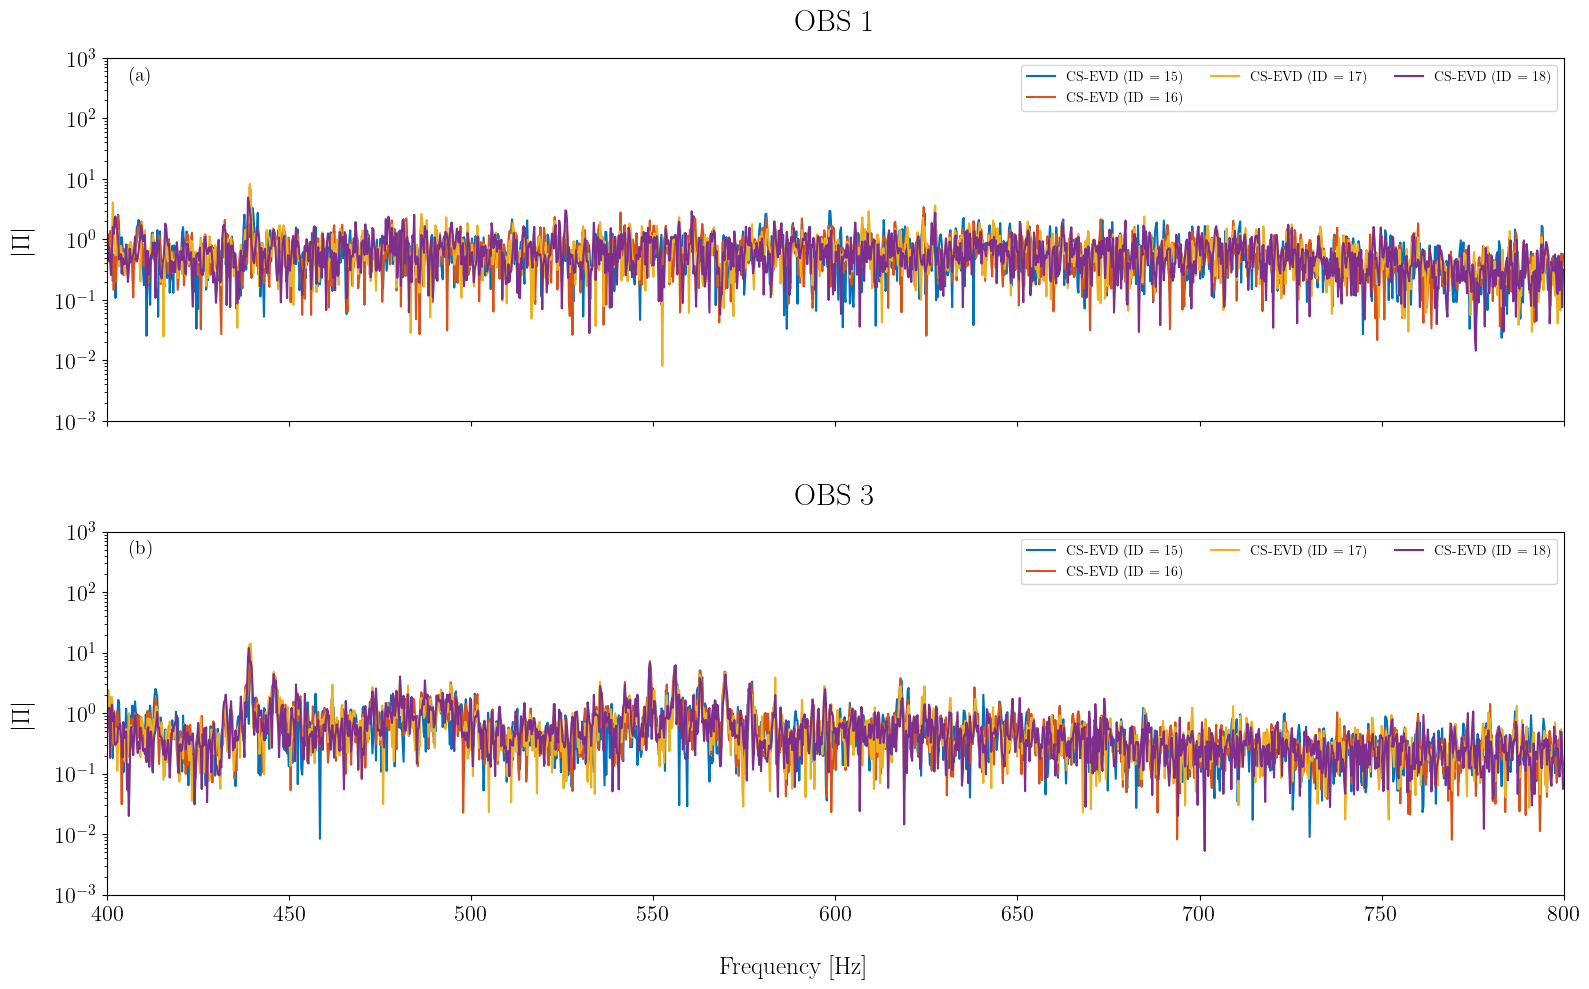

In [22]:
fmin_plot = 400
f_max_plot = 800

rep_var_selection = [15, 16, 17, 18]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    #
    # h_plot = i_rcv + 1
    h_plot = id_rcv

    for i, i_pulse in enumerate(rep_var_selection):

        ax_mod[i_ax].plot(
            freq,
            np.abs(rtf_cs_evd[i_rcv, :, i_pulse]),
            label=f"CS-EVD (ID = {i_pulse})",
            color=color(i),
        )
        # ax_mod[i_ax].plot(
        #     freq,
        #     np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
        #     label=f"Deconvolution interp (ID = {i_pulse})",
        #     color=color(i),
        #     linestyle="--",
        # )

        ax_mod[i_ax].set_title(f"OBS {h_plot}")
        ax_mod[i_ax].set_ylim([0.001, 1000])
        ax_mod[i_ax].set_yscale("log")
        ax_mod[i_ax].set_xlabel("")
        ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
        ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

# fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
# plt.savefig(fpath)

(400.0, 800.0)

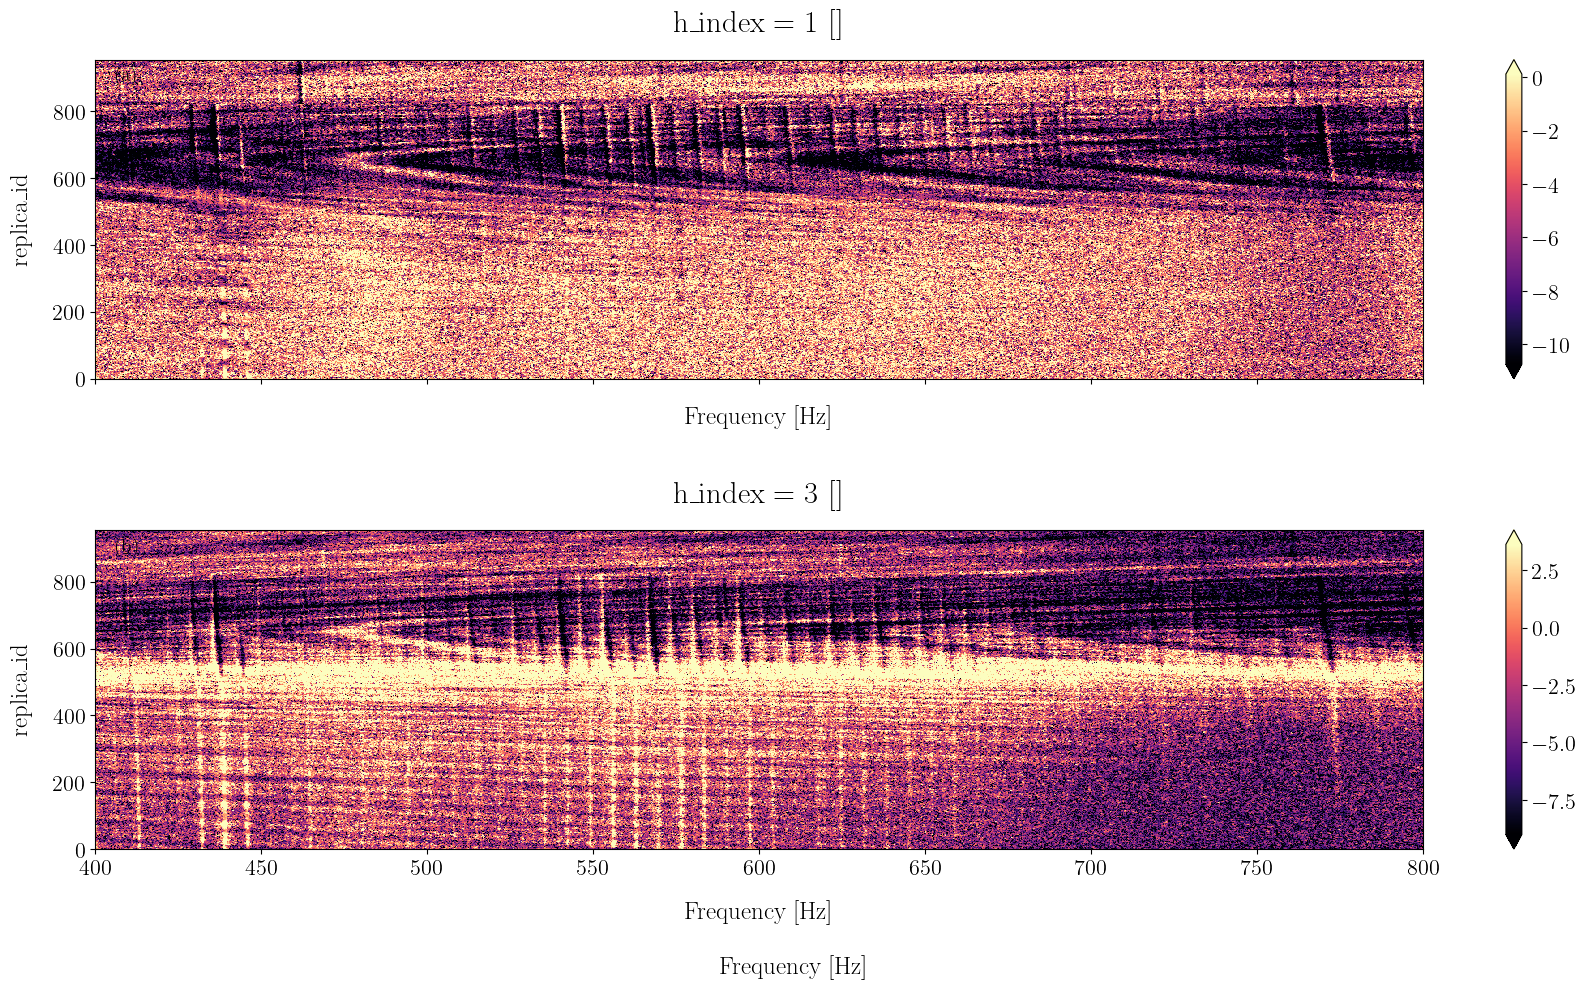

In [23]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

# # ?
replica_id_slice = slice(0, 1000)


# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)
    log_mod = 10 * np.log10(np.abs(rtf_cs_evd_rcv))
    log_mod.plot(
        x="f_rtf",
        cmap="magma",
        ax=ax_mod[i_ax],
        vmin=np.percentile(log_mod, 10),
        vmax=np.percentile(log_mod, 90),
    )



    # # h_plot = i_rcv + 1
    # h_plot = id_rcv

    # for i, i_pulse in enumerate(rep_var_selection):

    #     ax_mod[i_ax].plot(
    #         freq,
    #         np.abs(rtf_cs_evd[i_rcv, :, 100:150]),
    #         label=f"CS-EVD (ID = {i_pulse})",
    #         color=color(i),
    #     )
    #     # ax_mod[i_ax].plot(
    #     #     freq,
    #     #     np.abs(rtf_deconvolution_interp[i_rcv, :, i_pulse]),
    #     #     label=f"Deconvolution interp (ID = {i_pulse})",
    #     #     color=color(i),
    #     #     linestyle="--",
    #     # )

    #     ax_mod[i_ax].set_title(f"OBS {h_plot}")
    #     ax_mod[i_ax].set_ylim([0.001, 1000])
    #     ax_mod[i_ax].set_yscale("log")
    #     ax_mod[i_ax].set_xlabel("")
    #     ax_mod[i_ax].set_ylabel(r"$|\Pi|$")
    #     ax_mod[i_ax].legend(fontsize=10, ncol=3, loc="upper right")

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

# fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
# plt.savefig(fpath)

Text(0.5, 0.01, 'Frequency [Hz]')

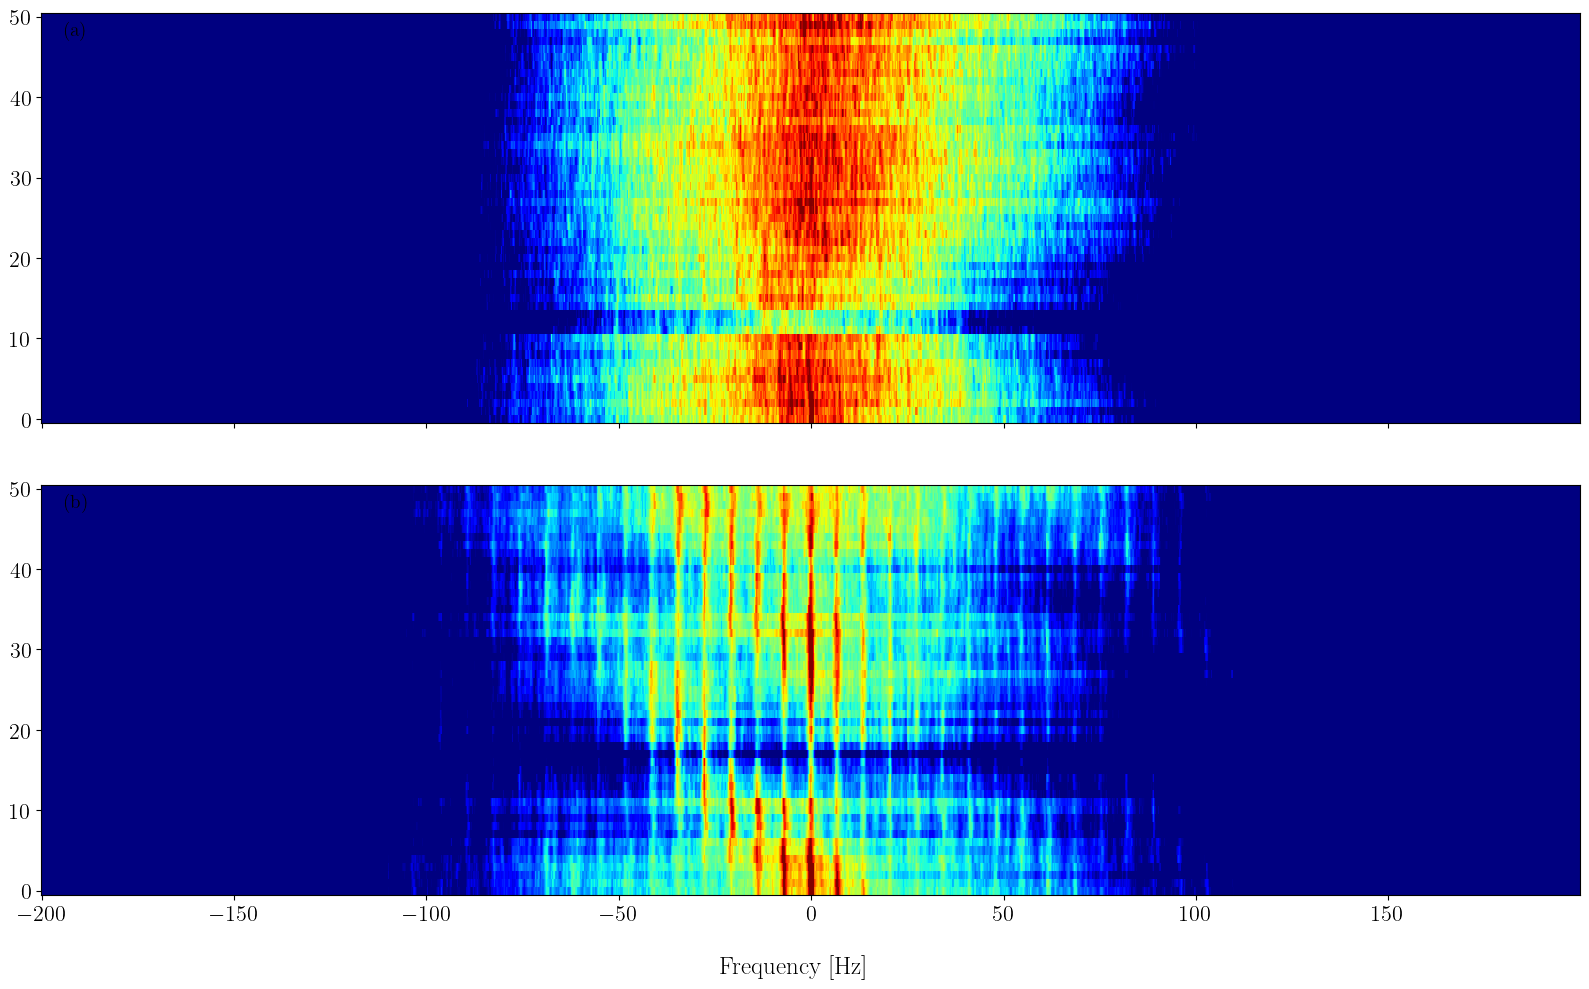

In [24]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_mod = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

#
replica_id_slice = slice(0, 50)


# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)
    # log_mod_cs_evd = 10 * np.log10(np.abs(rtf_cs_evd_rcv))
    log_mod_cs_evd = np.abs(rtf_cs_evd_rcv)
    # log_mod_cs_evd = rtf_cs_evd_rcv

    # rtf_deconvolution_rcv = rtf_deconvolution.sel(h_index=id_rcv).sel(
    #     replica_id=replica_id_slice
    # )
    # log_mod_deconv = 10 * np.log10(np.abs(rtf_deconvolution_rcv))

    corr = []
    sig_ref = log_mod_cs_evd.isel(replica_id=0).values

    for i_rep in rtf_cs_evd_rcv.replica_id.values:
        # Calcul de l'intercorrélation entre deux "signaux" de module
        sig = log_mod_cs_evd.sel(replica_id=i_rep).values

        autocorr_sig = np.correlate(sig, sig, mode="same")
        autocorr_sig_ref = np.correlate(sig_ref, sig_ref, mode="same")

        intercorr =  np.correlate(sig, sig_ref, mode="same")
        intercorr = intercorr / np.sqrt(autocorr_sig.max() * autocorr_sig_ref.max())

        corr.append(intercorr)

    corr = np.array(corr)

    step_f = rtf_cs_evd_rcv.f_rtf.values[1] - rtf_cs_evd_rcv.f_rtf.values[0]
    lags_f = sp.correlation_lags(sig.size, sig_ref.size, mode="same") * step_f

    # corr = np.abs(corr)
    # Plot
    ax_mod[i_ax].pcolormesh(
        lags_f,
        rtf_cs_evd_rcv.replica_id,
        corr,
        cmap="jet",
        vmin=np.percentile(corr, 60),
        vmax=np.percentile(corr, 99.9),
    )

    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")

# fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
# plt.savefig(fpath)

(400.0, 800.0)

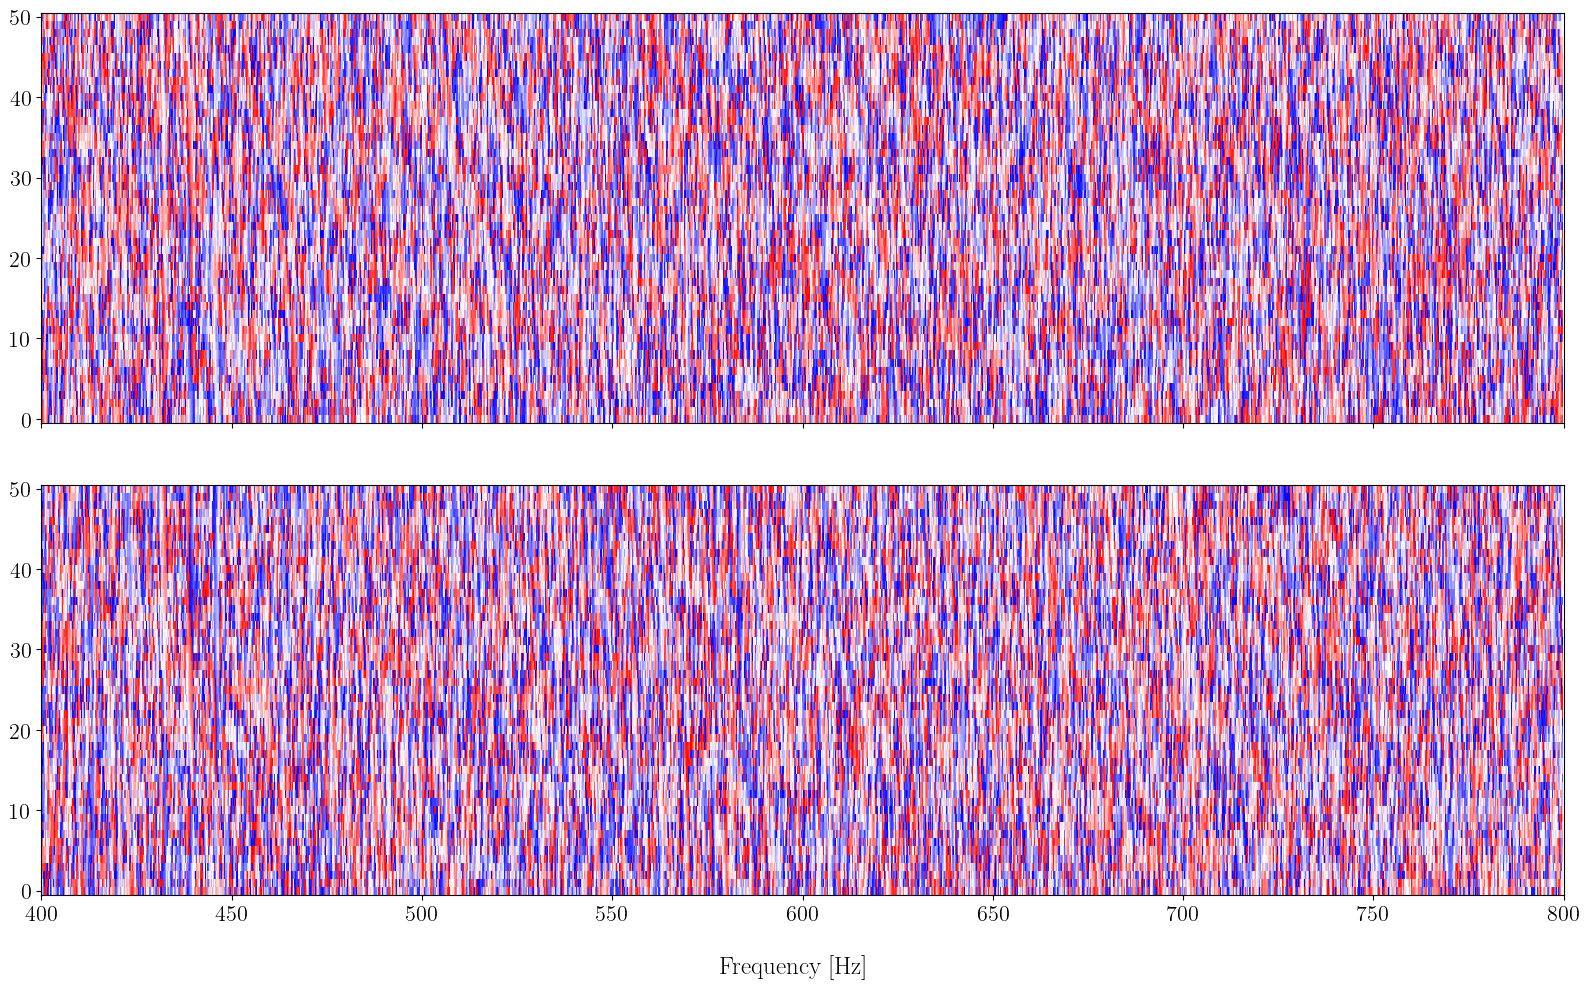

In [25]:
fmin_plot = 400
f_max_plot = 800

# rep_var_selection = [129, 130, 131, 132, 133]
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, ax_phase = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey="row", figsize=(16, 10)
)

replica_id_slice = slice(0, 50)
# Module
i_ax = 0
for id_rcv in idx_rcv_plot:
    i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))

    rtf_cs_evd_rcv = rtf_cs_evd.sel(h_index=id_rcv).sel(replica_id=replica_id_slice)
    phi_cs_evd = np.angle(rtf_cs_evd_rcv)
    ax_phase[i_ax].pcolormesh(
        rtf_cs_evd.f_rtf.values,
        rtf_cs_evd_rcv.replica_id,
        phi_cs_evd.T,
        cmap="bwr",
        vmin=-np.pi,
        vmax=np.pi,
    )


    i_ax += 1

set_subfigures_abc_labels(
    axs=ax_mod, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
plt.xlim([fmin_plot, f_max_plot])

# fpath = os.path.join(fig_folder, "rtf_module_at_identified_pos.png")
# plt.savefig(fpath)

# Bootstrap avec la déconvolution 


In [26]:
def get_bootstrap_dist(ds, test_replica_id):
    # Select one replica_id to compare using bootstrap
    test_replica = ds.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds


    # Test RTF
    test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

    # Other RTFs
    bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
        1j * bootstrap_replica.rtf_phase
    )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # # Compute dist
    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_hermitian_angle_fast(
    #     rtf_ref=test_replica_rtf.values,
    #     rtf=bootstrap_replica_rtfs,
    #     **dist_kwargs,
    # )

    rtf_ref = np.abs(test_replica_rtf.values)
    rtf = np.abs(bootstrap_replica_rtfs)
    dist = D_hermitian_angle_fast(
        rtf_ref=rtf_ref,
        rtf=rtf,
        **dist_kwargs,
    )

    # # EUCLIDEAN distance
    # d_rcv_1 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=1).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[0, ...]), axis=0
    # )
    # d_rcv_2 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=2).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[1, ...]),
    #     axis=0,
    # )
    # d_rcv_3 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=3).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[2, ...]),
    #     axis=0,
    # )
    # dist = 1 / 3 * (d_rcv_1 + d_rcv_2 + d_rcv_3)

    # # # Compute dist
    # dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_euclidian(
    #     rtf_ref=np.abs(test_replica_rtf.isel(h_index=slice(0, 1)).values),
    #     rtf=np.abs(bootstrap_replica_rtfs[0:1, ...]),
    #     **dist_kwargs,
    # )

    # # Expand rtf_ref along the necessary axes for broadcasting
    # rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

    # # Calculate euclidian distance
    # # d_euc = np.sqrt(np.sum(np.abs(rtf_ref_expanded - rtf) ** 2, axis=1))
    # dist = np.linalg.norm(rtf_ref_expanded - rtf, axis=1)

    return dist 

In [27]:
def get_bootstrap_dist_matrix(ds):
    dist_mat = []
    for i, id in enumerate(ds.replica_id.values): 
        dist_id = get_bootstrap_dist(ds=ds, test_replica_id=id)
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal 
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [28]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)


In [29]:
theta_mat = get_bootstrap_dist_matrix(ds=ds)

In [30]:
dist_rcv = get_dist_to_rcv(ds=ds)

Text(0.5, 0, 'Replica index')

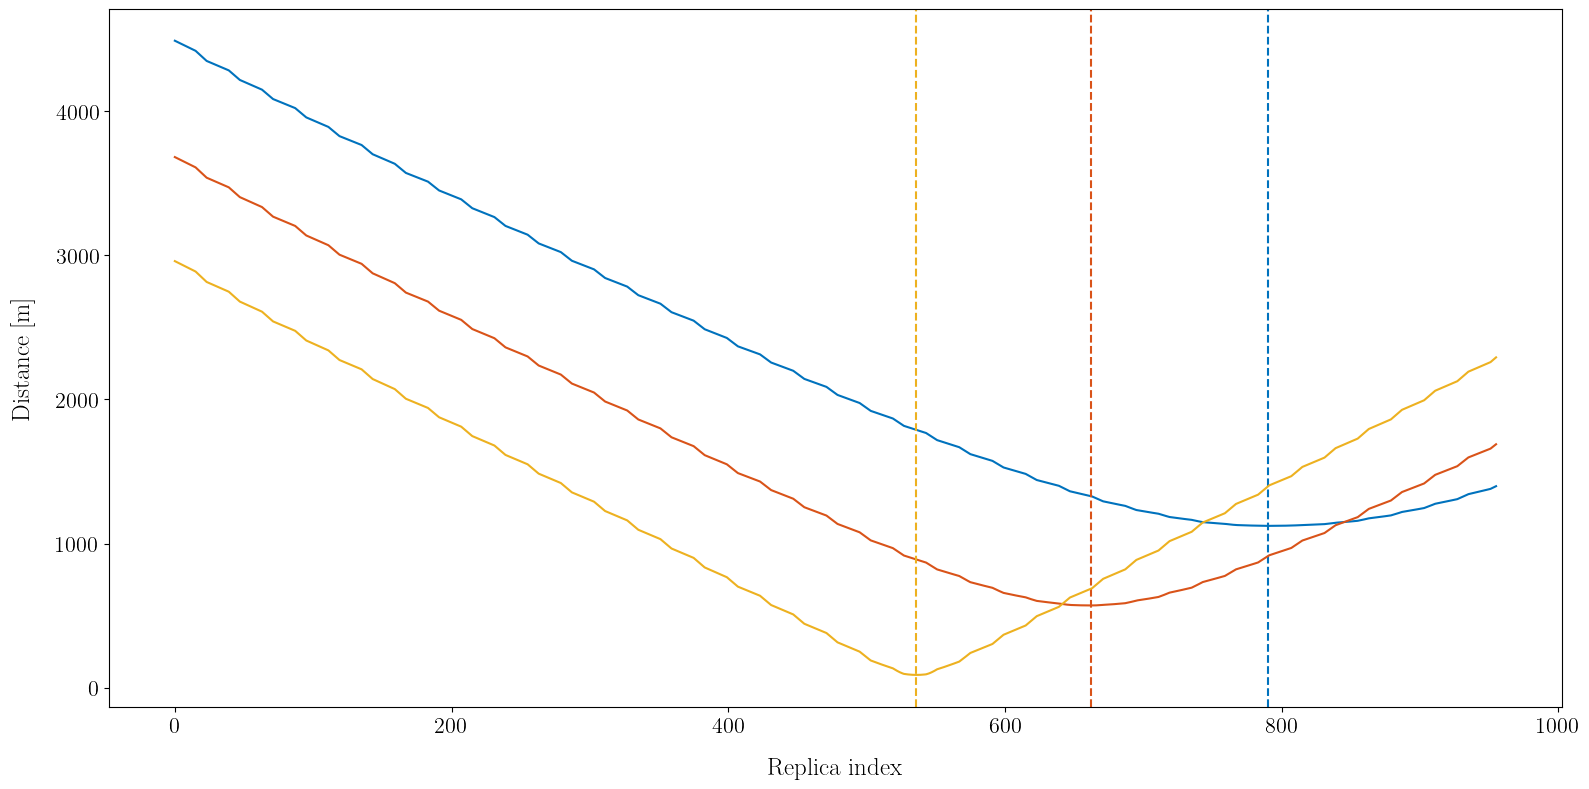

In [31]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_29628\1081671111.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(fpath)


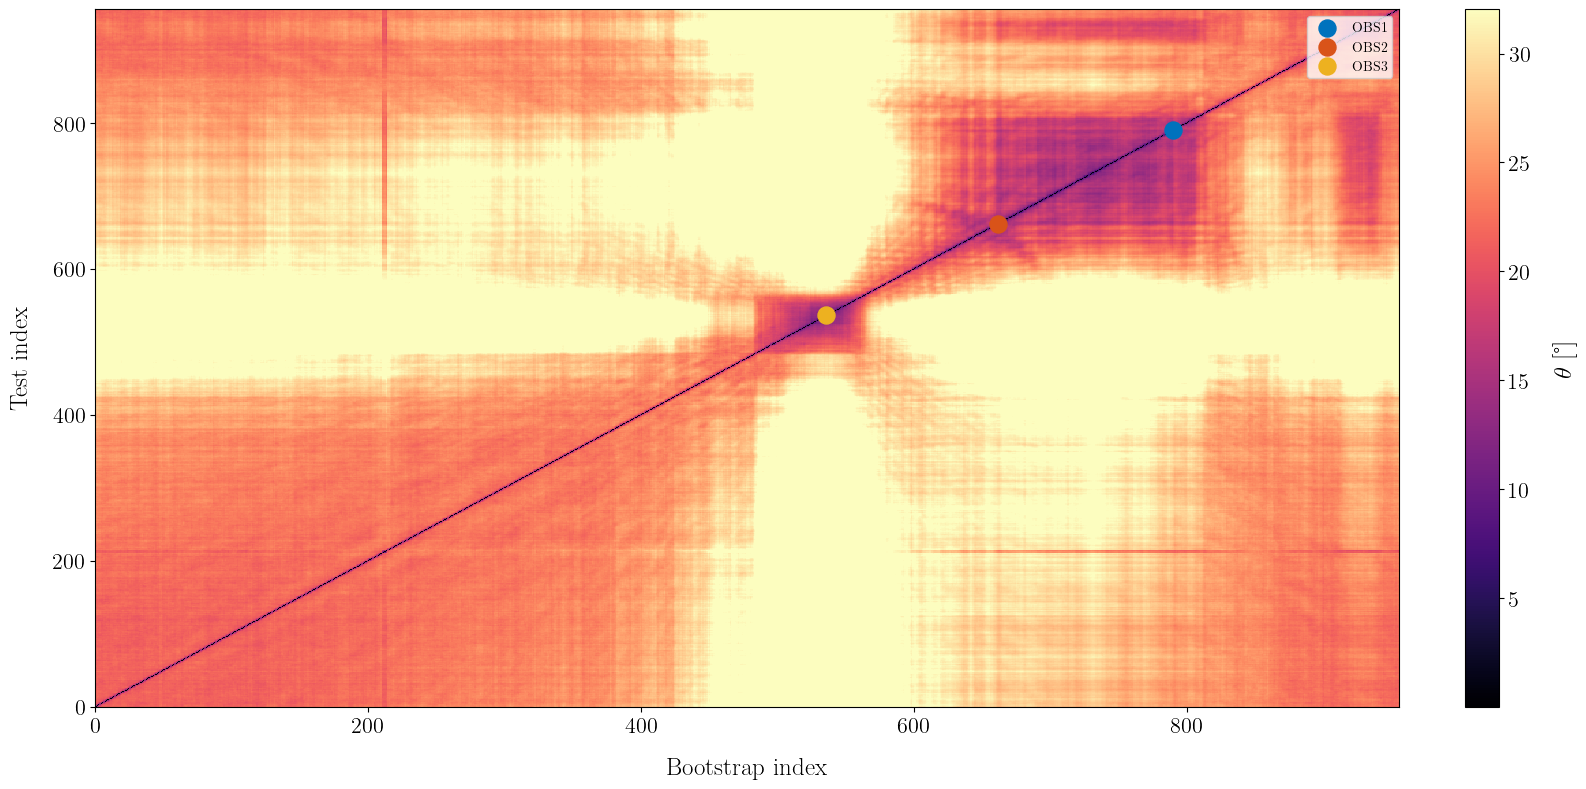

In [32]:
vmax = np.nanpercentile(theta_mat, 75)

plt.figure()
im = plt.pcolormesh(theta_mat, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")

# Add CPA indication
for i, i_rcv in enumerate(ds.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=150, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_event_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

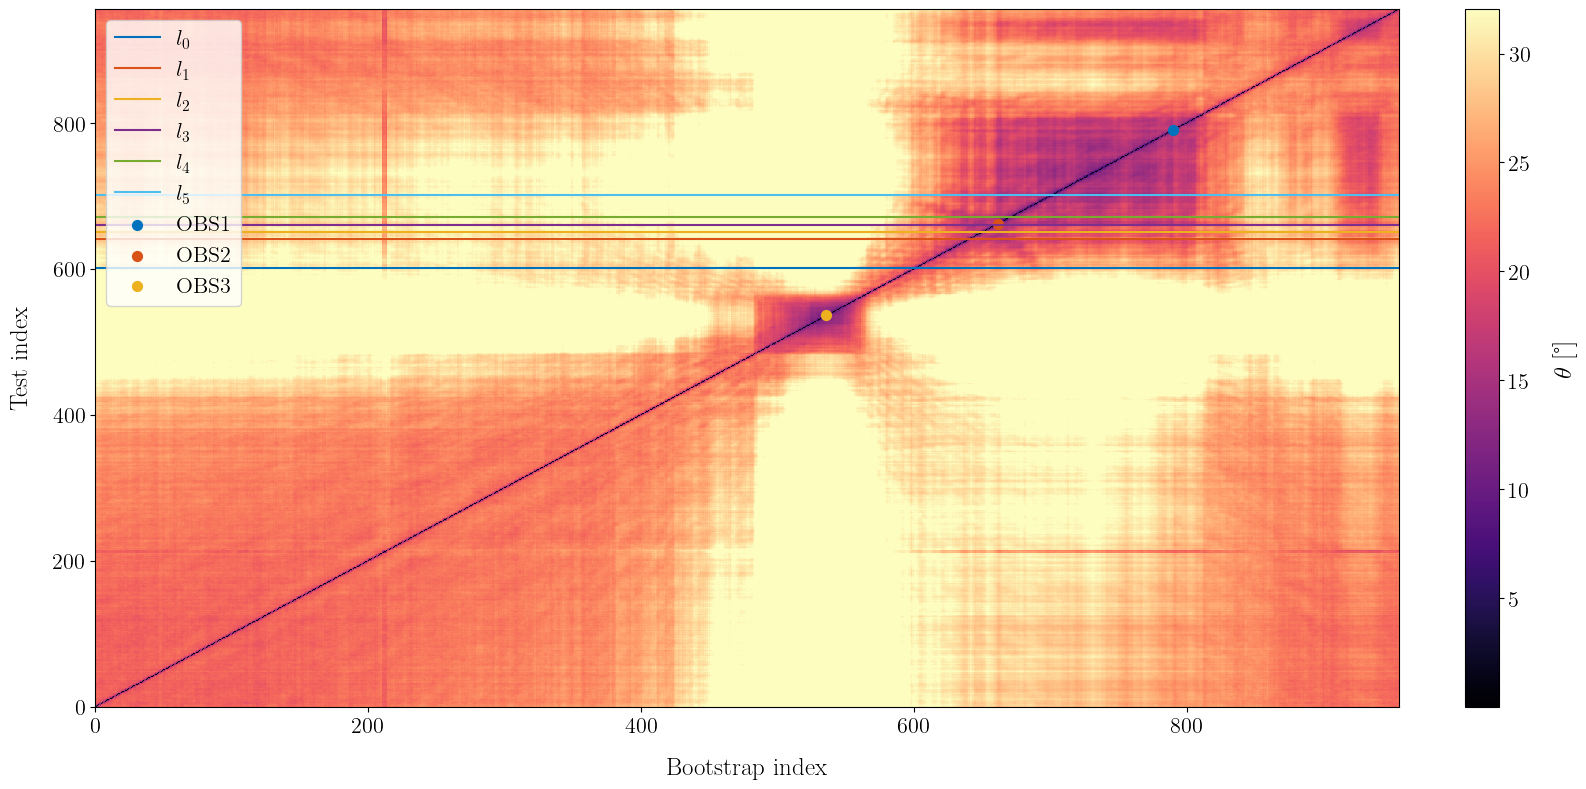

In [33]:
# Quelques lignes à la loupe
# i_ls = [325, 650, 800, 900]
i_ls = [600, 640, 650, 660, 670, 700]

# i_ls = rep_selection

plt.figure()
im = plt.pcolormesh(
    theta_mat, cmap="magma", vmax=vmax
)
for k, i_l in enumerate(i_ls):
    plt.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$")

plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=50, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend(fontsize=16, loc="upper left")

# fpath = os.path.join(
#     root_img,
#     f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_lines.png",
# )
# plt.savefig(fpath)

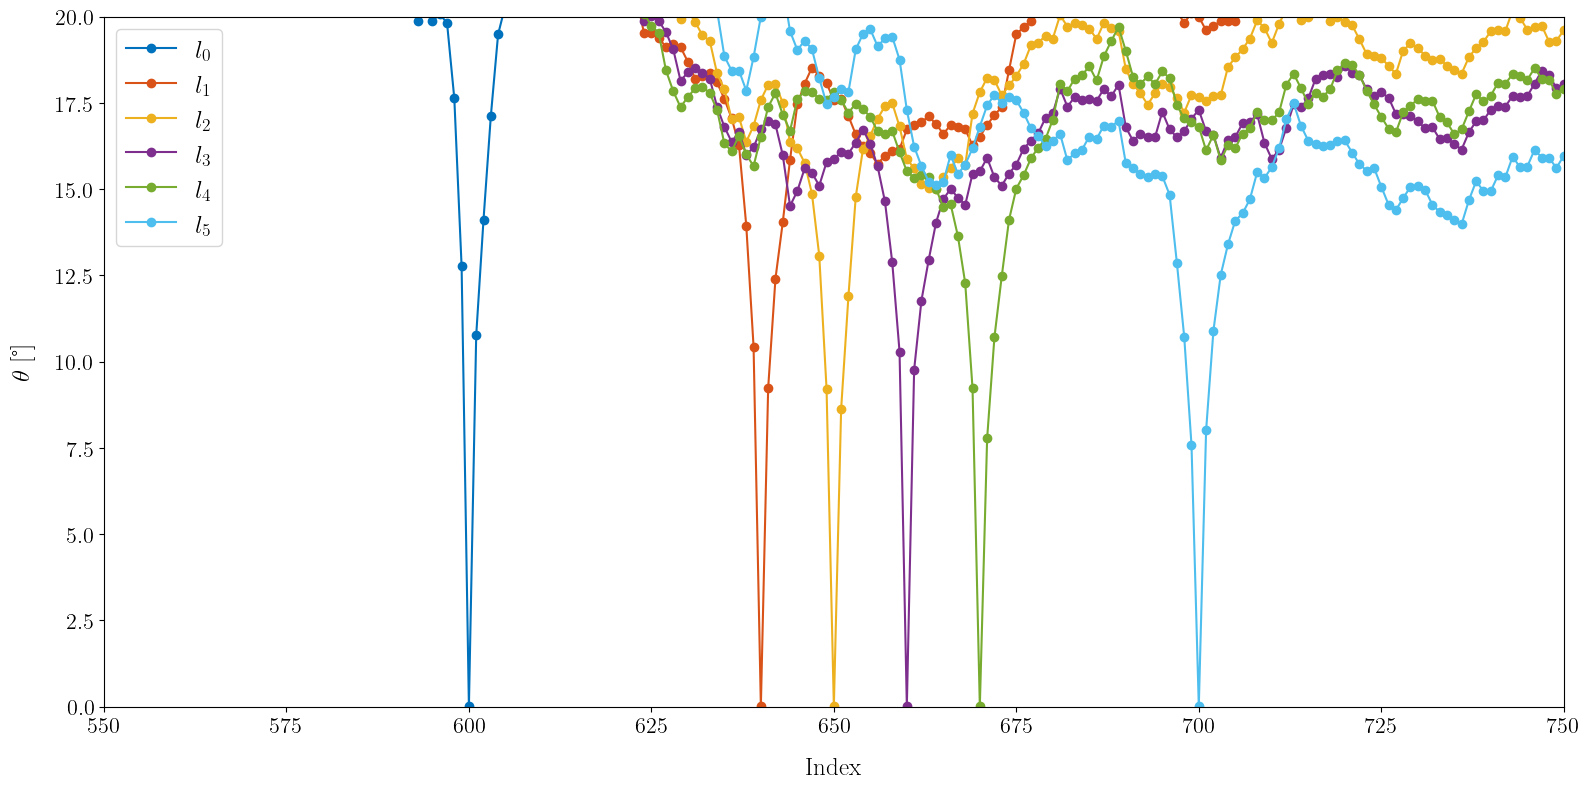

In [34]:
plt.figure()
for k, i_l in enumerate(i_ls):
    plt.plot(theta_mat[i_l, :], marker="o", color=color(k), label=rf"$l_{k}$")

plt.legend(fontsize=18)
plt.xlabel("Index")
plt.ylabel(r"$\theta$ [°]")
plt.ylim([0, 20])
plt.xlim([550, 750])

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_asymetry.png",
)
plt.savefig(fpath)

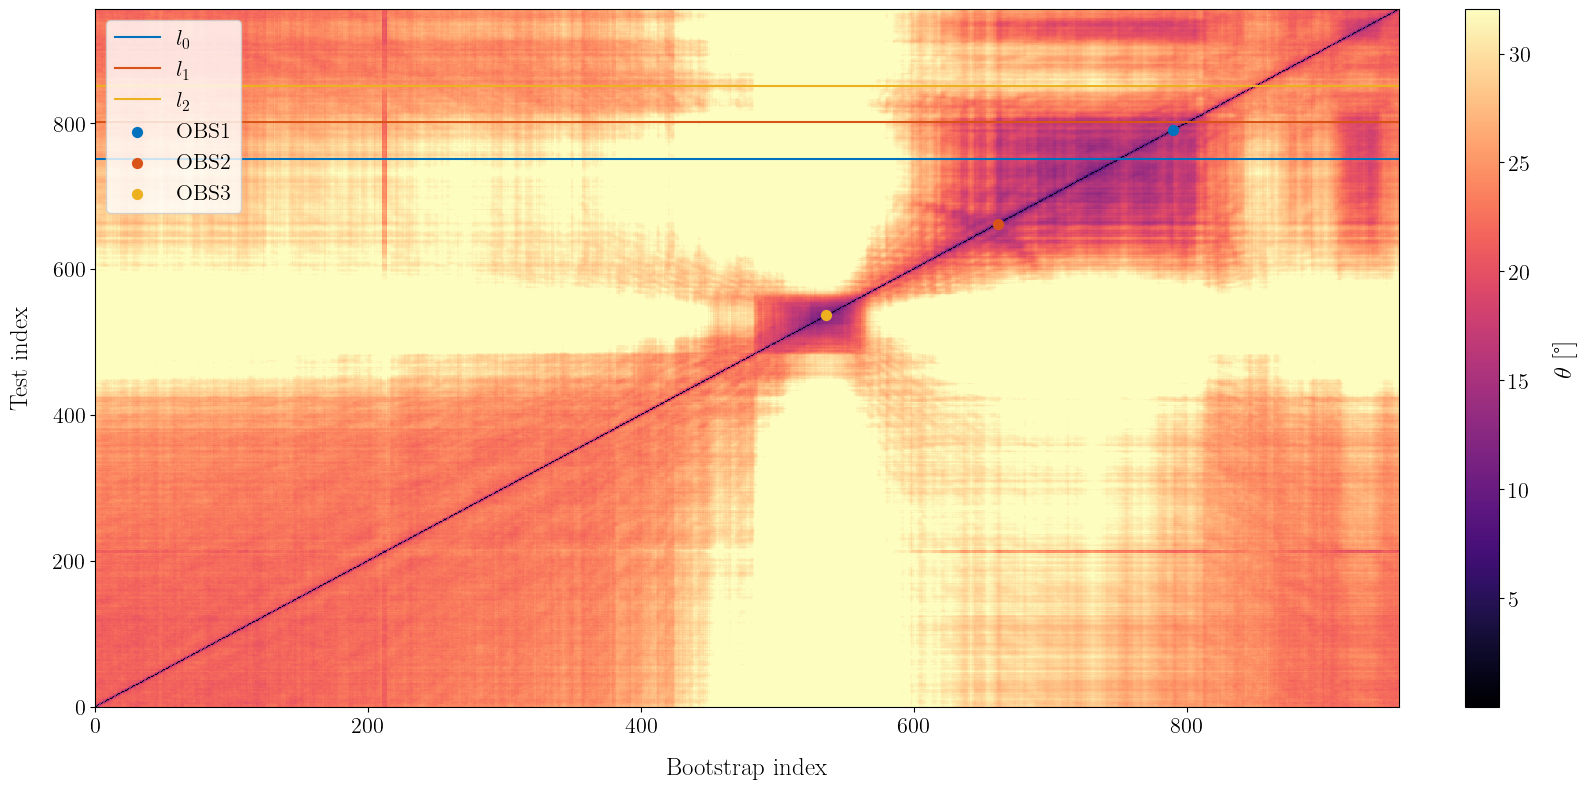

In [35]:
# Quelques lignes à la loupe
# i_ls = [325, 650, 800, 900]
i_ls = [750, 800, 850]

# i_ls = rep_selection

plt.figure()
im = plt.pcolormesh(
    theta_mat, cmap="magma", vmax=vmax
)
for k, i_l in enumerate(i_ls):
    plt.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$")

plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=50, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend(fontsize=16, loc="upper left")

# fpath = os.path.join(
#     root_img,
#     f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_lines.png",
# )
# plt.savefig(fpath)

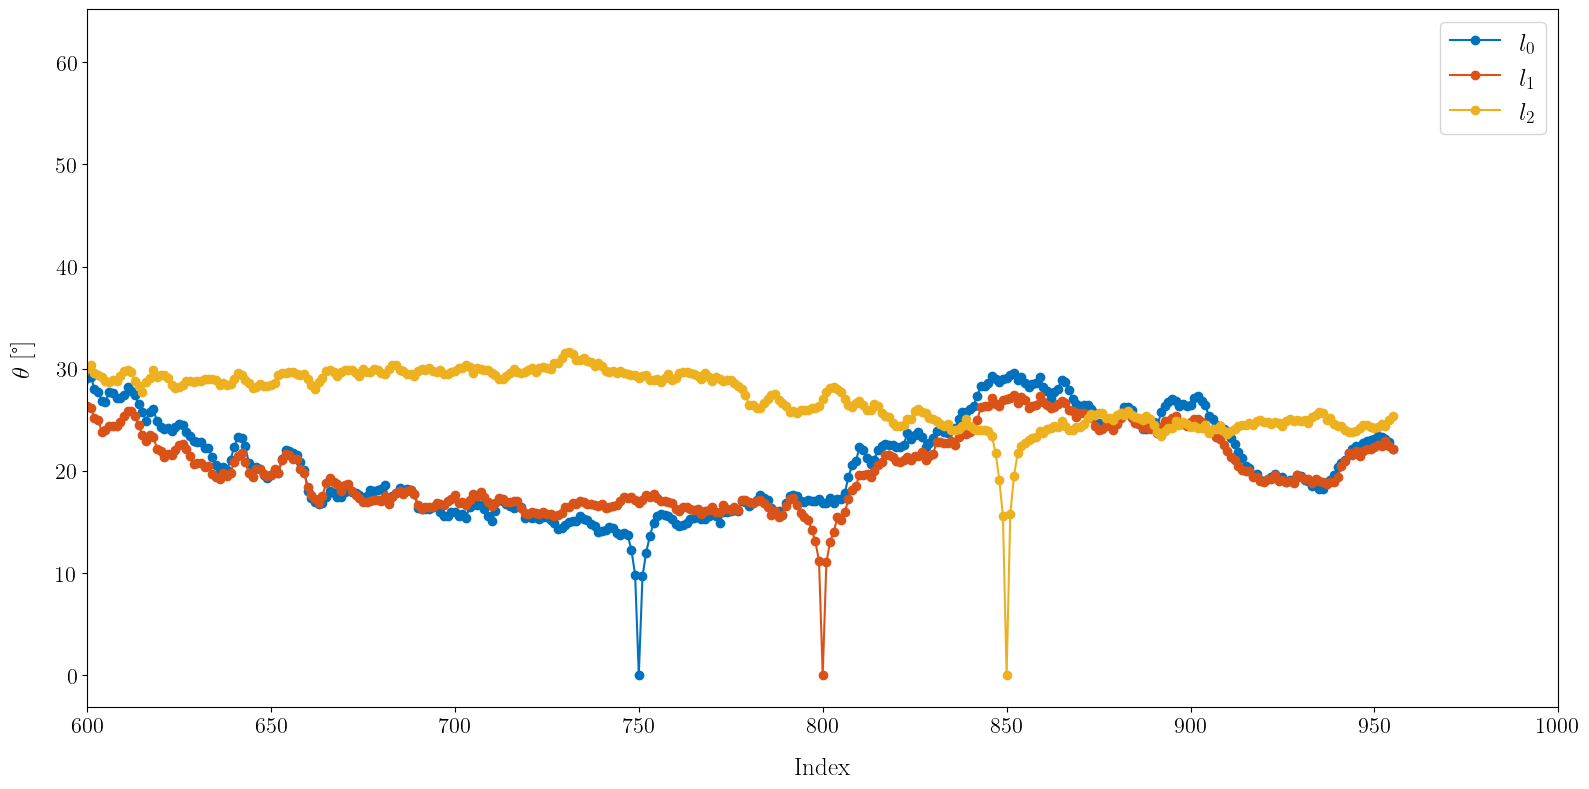

In [36]:
plt.figure()
for k, i_l in enumerate(i_ls):
    plt.plot(theta_mat[i_l, :], marker="o", color=color(k), label=rf"$l_{k}$")

plt.legend(fontsize=18)
plt.xlabel("Index")
plt.ylabel(r"$\theta$ [°]")
# plt.ylim([0, 20])
plt.xlim([600, 1000])

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_asymetry.png",
)
plt.savefig(fpath)